# Tutorial 8: Fitting a Hanger Resonator

Tutorials 1–3 fitted series resonators where the resonance shows up as a **peak** in $|S_{21}|$. However, many readout chips
instead use a **hanger** (notch) resonators that hangs off a continuous through
feedline. Here, the resonance appears as a **dip** in
$|S_{21}|$:

In this tutorial you will learn how to use **simpleLOMs** to

1. **build** a CPW hanger and look at its notch,
2. Turn an existing or new  `OptimizedFit` into a hanger
3. Fit a hanger LOM explicitly with  with `fit_lom_hanger` and `HangerOptimizedFit` to match the notch in $|S_{21}|$.



In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import skrf as rf

import simpleLOMs as sl


sl.apply_style()

cpw = sl.CPWParams(ep_r=11.45)
Z0 = 50.0
d = 7.0e-3          # resonator length (m)
Cc_tap = 30e-15     # coupling (F)
freq = rf.Frequency(3e9, 12e9, 8001, unit="Hz")

print("geometry: d = {:.1f} mm,  Cc_tap = {:.0f} fF".format(d * 1e3, Cc_tap * 1e15))


geometry: d = 7.0 mm,  Cc_tap = 30 fF


## 1. Build the CPW hanger

`hanger_resonator_network_2port` takes a list of hanging segments and one tap
capacitance per segment. An open termination, which we use here, is the $\lambda/2$ hanger, while
 a shorted termination is the $\lambda/4$ hanger.


In [3]:
cpw_open = sl.hanger_resonator_network_2port(
    freq,
    [{"kind": "cpw", "d": d, "termination": "open"}],
    [Cc_tap],
    cpw_params=cpw,
    Z0=Z0,
)
cpw_short = sl.hanger_resonator_network_2port(
    freq,
    [{"kind": "cpw", "d": d, "termination": "short"}],
    [Cc_tap],
    cpw_params=cpw,
    Z0=Z0,
)

f_open, dp_open = sl.notch_frequency(cpw_open)
f_short, dp_short = sl.notch_frequency(cpw_short)
print("CPW open  (lambda/2):  notch at {:.3f} GHz,  |S21| = {:.3f}".format(f_open, dp_open))
print("CPW short (lambda/4):  notch at {:.3f} GHz,  |S21| = {:.3f}".format(f_short, dp_short))


CPW open  (lambda/2):  notch at 8.383 GHz,  |S21| = 0.026
CPW short (lambda/4):  notch at 4.191 GHz,  |S21| = 0.022


In [4]:
sl.hanger_resonator_schematic_2port(
    [{"kind": "cpw", "d": d, "termination": "open"}],
    [Cc_tap],
)


Schematic(meta={'title': '', 'description': '', 'source': 'simpleLOMs.networks.hanger.hanger_resonator_network_2port', 'units': {'capacitance': 'F', 'inductance': 'H', 'length': 'm', 'impedance': 'ohm', 'frequency': 'Hz'}}, groups=[{'id': 'hang1', 'label': 'hanger 1'}], components=[Component(id='P1', type='port', label='Port 1', value='50.00 \\Omega', ports=['out'], group=None, orient='series', props={'Z0': 50}), Component(id='H1', type='branch', label='', value='', ports=['a', 'gnd'], group='hang1', orient='shunt', props={'stack': [{'type': 'cap', 'label': 'C_{c1}', 'value': '30.00 fF'}, {'type': 'tline', 'label': 'CPW 1', 'value': '\\ell = 7.00 mm (open)'}]}), Component(id='P2', type='port', label='Port 2', value='50.00 \\Omega', ports=['in'], group=None, orient='series', props={'Z0': 50})], nets=[Net(id='n1', ports=['P1.out', 'H1.a']), Net(id='n2', ports=['H1.gnd', 'GND']), Net(id='n3', ports=['P1.out', 'P2.in'])], annotations={})

## 2. Option 1 — rewire an inline `OptimizedFit`

If you already fit a `LC` tank to your resonator against a series CPW with two-sided coupling
using the `fit_lom` / `OptimizedFit` methods of Tutorial 1, dropping those values into a single-tap hanger is the quick
path.

As an example here we can use a new `OptimizedFit` instance to calibrate $(L, C)$ for the hanger by rewiring it into a hanger.




In [ ]:

Cc1 = Cc2 = Cc_tap
freq_fit = rf.Frequency(7e9, 9e9, 3001, unit="Hz")
 
def reuse_inline(Ctog):
    "Fit an inline LOM at the given ground loading, then rewire into a hanger."
    L, C = sl.fit_lom(
        d, model="optimized",
        Cc1=Cc1, Cc2=Cc2, Ctog1=Ctog, Ctog2=Ctog,
        cpw_params=cpw, freq=freq_fit, Z0=Z0,
    )
    net = sl.hanger_resonator_network_2port(
        freq, [{"kind": "lc", "L": L, "C": C}], [Cc_tap], Z0=Z0,
    )
    f_r, dp = sl.notch_frequency(net)
    return L, C, net, f_r, dp


# Matched reuse: drop the inline grounds to mirror the ground-free hanger tap.
L_inline, C_inline, lc_reused, f_reuse, dp_reuse = reuse_inline(0.0)
err_reuse = 100.0 * (f_reuse - f_open) / f_open


print("matched reuse (Ctog =  0 fF):  L = {:.4f} nH,  C = {:.4f} pF".format(
    L_inline * 1e9, C_inline * 1e12))
print("                               notch at {:.3f} GHz  ({:+.3f} % vs CPW open)".format(
    f_reuse, err_reuse))


NameError: name 'Cc_tap' is not defined

## 3. Option 2 — fit a hanger LOM with `fit_lom_hanger`

Instead of rewiring an inline fit, you can instead fit the hanger directly. `fit_lom_hanger`
builds a CPW hanger reference and runs `HangerOptimizedFit` against the S21
notch, instead of the Re(S11)/Im(S11) pair that is used in `OptimizedFit`.

Let's try to use `fit_lom_hanger` for our device geometry.


In [ ]:
hanger_model = sl.fit_lom_hanger(
    d,
    Cc_tap=Cc_tap,
    termination="open",
    cpw_params=cpw,
    freq=freq,
    Z0=Z0,
    return_model=True,
)
print(hanger_model)
print("L = {:.4f} nH,  C = {:.4f} pF".format(
    hanger_model.L * 1e9, hanger_model.C * 1e12))

lc_fitted = hanger_model.get_network(freq, Cc_tap=Cc_tap, Z0=Z0)
f_fit, dp_fit = sl.notch_frequency(lc_fitted)


HangerOptimizedFit(L=5.5415e-10 H, C=6.2046e-13 F)
L = 0.5542 nH,  C = 0.6205 pF
hanger-fitted LC:     notch at 8.383 GHz  (-0.000 % vs CPW open)


## 4. Compare the notches



We can now look at the error in the notch feature between these two methods.

In [ ]:
err_fit = 100.0 * (f_fit - f_open) / f_open
print("hanger-fitted LC:     notch at {:.3f} GHz  ({:+.3f} % vs CPW open)".format(
    f_fit, err_fit))

Then, we can plot $|S_{21}|$ for the two methods (using `OptimizedFit` and `HangerOptimizedFit` respectively) to see whether the resonance feature is captured.

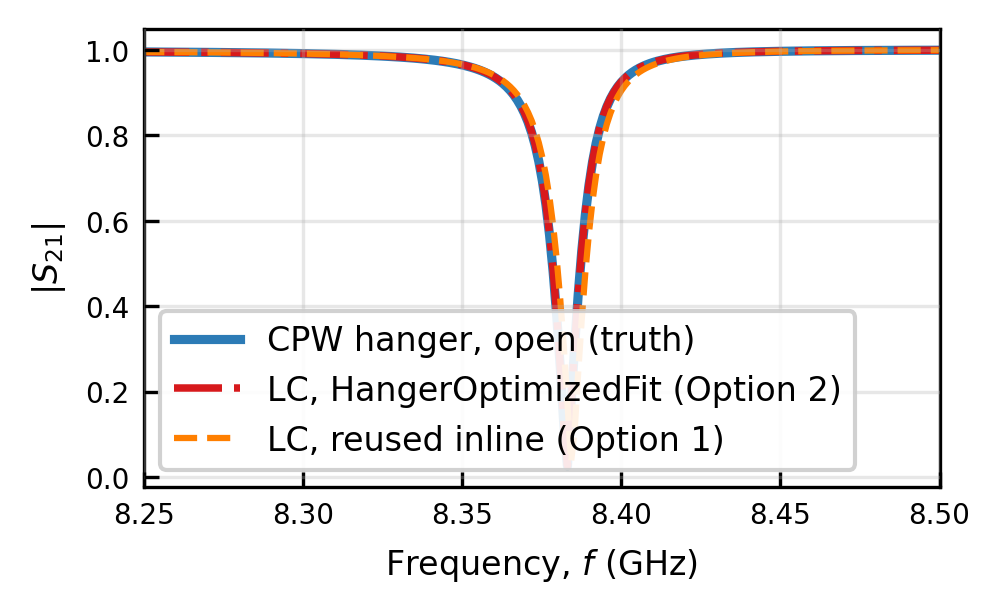

network                           notch GHz   err %   |S21|
--------------------------------  ---------  ------  ------
CPW open (truth)                     8.3829       —  0.0257
LC reuse, Ctog=20 fF (naive)         8.1319  -2.995  0.0505
LC reuse, Ctog=0 (Option 1)          8.3845  +0.019  0.0348
LC HangerOptimizedFit (Option 2)     8.3829  -0.000  0.0260


In [7]:
f_ghz = freq.f / 1e9
sl.plot_curves(
    f_ghz,
    (np.abs(cpw_open.s[:, 1, 0]), "CPW hanger, open (truth)",
     dict(color=sl.COLOR_PRIMARY, lw=2.2)),
    (np.abs(lc_fitted.s[:, 1, 0]), "LC, HangerOptimizedFit (Option 2)",
     dict(color=sl.COLOR_HIGHLIGHT, lw=1.8, ls="-.")),
    (np.abs(lc_reused.s[:, 1, 0]), "LC, reused inline (Option 1)",
     dict(color=sl.COLOR_SECONDARY, lw=1.5, ls="--")),
    xlabel=sl.LABEL_FREQ,
    ylabel=r"$|S_{21}|$",
    xlim=(8.25, 8.5),
)

print(sl.utils.format_comparison_table(
    [
        ("CPW open (truth)", "{:.4f}".format(f_open), "—", "{:.4f}".format(dp_open)),
        ("LC reuse, Ctog=20 fF (naive)", "{:.4f}".format(f_bad), "{:+.3f}".format(err_bad), "{:.4f}".format(dp_bad)),
        ("LC reuse, Ctog=0 (Option 1)", "{:.4f}".format(f_reuse), "{:+.3f}".format(err_reuse), "{:.4f}".format(dp_reuse)),
        ("LC HangerOptimizedFit (Option 2)", "{:.4f}".format(f_fit), "{:+.3f}".format(err_fit), "{:.4f}".format(dp_fit)),
    ],
    ["network", "notch GHz", "err %", "|S21|"],
))


Although both methods reproduce the notch frequency quite well, only the dedicated fit
also reproduces the notch depth.


## 5. Draw the fitted LOM hanger

As usual we can draw the fitted hanger using the schematic builder, which uses the same segment dicts as the network API. 

Let's plot the lumped model we fitted using Option 2.


In [8]:
sl.hanger_resonator_schematic_2port(
    [{"kind": "lc", "L": hanger_model.L, "C": hanger_model.C}],
    [Cc_tap],
)


Schematic(meta={'title': '', 'description': '', 'source': 'simpleLOMs.networks.hanger.hanger_resonator_network_2port', 'units': {'capacitance': 'F', 'inductance': 'H', 'length': 'm', 'impedance': 'ohm', 'frequency': 'Hz'}}, groups=[{'id': 'hang1', 'label': 'hanger 1'}], components=[Component(id='P1', type='port', label='Port 1', value='50.00 \\Omega', ports=['out'], group=None, orient='series', props={'Z0': 50}), Component(id='H1', type='branch', label='', value='', ports=['a', 'gnd'], group='hang1', orient='shunt', props={'stack': [{'type': 'cap', 'label': 'C_{c1}', 'value': '30.00 fF'}, {'type': 'lc', 'label': 'LC 1', 'value': 'L = 554.15 pH\nC = 620.46 fF'}]}), Component(id='P2', type='port', label='Port 2', value='50.00 \\Omega', ports=['in'], group=None, orient='series', props={'Z0': 50})], nets=[Net(id='n1', ports=['P1.out', 'H1.a']), Net(id='n2', ports=['H1.gnd', 'GND']), Net(id='n3', ports=['P1.out', 'P2.in'])], annotations={})

This can now be saved or exported for further use.

## 6. Multiple hangers on one feedline

Much line in Tutorial 3, resonator networks with multiple hangers on the same feedline can be constructed.

To do so, we will pass several segments (and one `Cc` per segment) to put several notches on the
same through line. Fit each resonator
in isolation with `fit_lom_hanger` at its own length, then reassemble.


### 6a. Constructing the network
First we construct the network with our CPW from before and a CPW at a length of $8000$ mm.

In [ ]:
d2 = 8.0e-3
cpw_two = sl.hanger_resonator_network_2port(
    freq,
    [
        {"kind": "cpw", "d": d,  "termination": "open"},
        {"kind": "cpw", "d": d2, "termination": "open"},
    ],
    [Cc_tap, Cc_tap],
    cpw_params=cpw,
    Z0=Z0,
)


Next we fit the LOM for each individual resonator using `fit_lom_hanger`.

In [ ]:
L1, C1 = sl.fit_lom_hanger(d,  Cc_tap=Cc_tap, termination="open",
                           cpw_params=cpw, freq=freq, Z0=Z0)
L2, C2 = sl.fit_lom_hanger(d2, Cc_tap=Cc_tap, termination="open",
                           cpw_params=cpw, freq=freq, Z0=Z0)

We now reconstruct the LC-fitted network.

In [ ]:
lc_two = sl.hanger_resonator_network_2port(
    freq,
    [
        {"kind": "lc", "L": L1, "C": C1},
        {"kind": "lc", "L": L2, "C": C2},
    ],
    [Cc_tap, Cc_tap],
    Z0=Z0,
)

### 6b. Comparing LC and CPW networks

Now we can plot the curved to see how the LC behaves compared to the network.

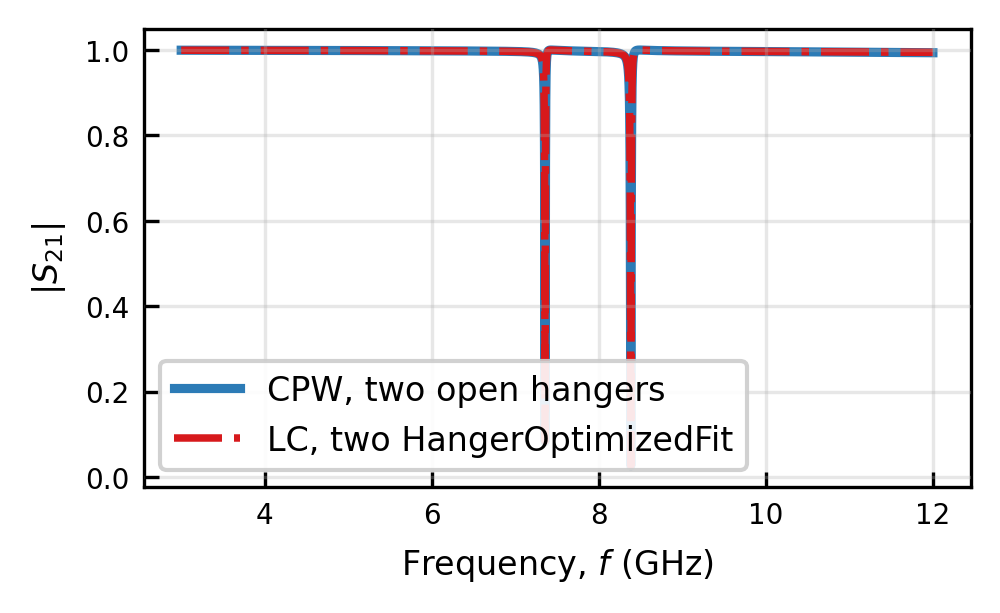

CPW notches (GHz): ['7.356', '8.383']
LC  notches (GHz): ['7.356', '8.383']


In [ ]:
sl.plot_curves(
    freq.f / 1e9,
    (np.abs(cpw_two.s[:, 1, 0]), "CPW",
     dict(color=sl.COLOR_PRIMARY, lw=2.2)),
    (np.abs(lc_two.s[:, 1, 0]), "LC, HangerOptimizedFit",
     dict(color=sl.COLOR_HIGHLIGHT, lw=1.8, ls="-.")),
    xlabel=sl.LABEL_FREQ,
    ylabel=r"$|S_{21}|$",
)

The notches are very close! To be sure, we can print their frequencies and compare them numerically.

In [ ]:
print("CPW notches (GHz):", ["{:.3f}".format(x) for x in sl.notches_below(cpw_two)])
print("LC  notches (GHz):", ["{:.3f}".format(x) for x in sl.notches_below(lc_two)])


Finally we can make a schematic of the fitted system and export it. As we can see, the fitted system has the same two-hanger topology as the CPW hanger system.

In [ ]:

sl.hanger_resonator_schematic_2port(
    [
        {"kind": "lc", "L": L1, "C": C1},
        {"kind": "lc", "L": L2, "C": C2},
    ],
    [Cc_tap, Cc_tap],
)


Schematic(meta={'title': '', 'description': '', 'source': 'simpleLOMs.networks.hanger.hanger_resonator_network_2port', 'units': {'capacitance': 'F', 'inductance': 'H', 'length': 'm', 'impedance': 'ohm', 'frequency': 'Hz'}}, groups=[{'id': 'hang1', 'label': 'hanger 1'}, {'id': 'hang2', 'label': 'hanger 2'}], components=[Component(id='P1', type='port', label='Port 1', value='50.00 \\Omega', ports=['out'], group=None, orient='series', props={'Z0': 50}), Component(id='H1', type='branch', label='', value='', ports=['a', 'gnd'], group='hang1', orient='shunt', props={'stack': [{'type': 'cap', 'label': 'C_{c1}', 'value': '30.00 fF'}, {'type': 'lc', 'label': 'LC 1', 'value': 'L = 554.15 pH\nC = 620.46 fF'}]}), Component(id='H2', type='branch', label='', value='', ports=['a', 'gnd'], group='hang2', orient='shunt', props={'stack': [{'type': 'cap', 'label': 'C_{c2}', 'value': '30.00 fF'}, {'type': 'lc', 'label': 'LC 2', 'value': 'L = 630.97 pH\nC = 711.81 fF'}]}), Component(id='P2', type='port', label='Port 2', value='50.00 \\Omega', ports=['in'], group=None, orient='series', props={'Z0': 50})], nets=[Net(id='n1', ports=['P1.out', 'H1.a']), Net(id='n2', ports=['H1.gnd', 'GND']), Net(id='n3', ports=['P1.out', 'H2.a']), Net(id='n4', ports=['H2.gnd', 'GND']), Net(id='n5', ports=['P1.out', 'P2.in'])], annotations={})

## What next?

In the next tutorial, Tutorial 9, we will see how to cascade a series resonator (Tutorial 1, 3) with hanger resonators (this tutorial) to make networks that include both.
